# Practical plotting with seaborn and matplotlib - exercises

This companion notebook repeats the tutorial exercises and provides compact
reference solutions. Most exercises use `penguins`, while the tutorial examples
use `tips` and `flights` where possible.

Import the plotting libraries and set a readable default theme.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

Load the datasets once so all exercise solutions use the same prepared objects.

In [2]:
penguins = sns.load_dataset("penguins")
flights = sns.load_dataset("flights")
flights["period"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b",
)
measurement_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
species_order = list(penguins["species"].dropna().unique())

In [3]:
species_order

['Adelie', 'Chinstrap', 'Gentoo']

## Exercise 1: First seaborn plot

1. Inspect `penguins` with `.head(3)` and `.info()`.
2. Drop rows with missing `sex`, `flipper_length_mm`, or `body_mass_g`.
3. Create a scatter plot of `flipper_length_mm` vs. `body_mass_g`.
4. Encode `species` with `hue` and `sex` with `style`.
5. Add the title `Penguin body mass by flipper length`.
6. Label the axes `Flipper length (mm)` and `Body mass (g)`.
7. BONUS: Set `alpha=0.75` to reduce overplotting.
8. BONUS: Create a second version without `style="sex"` and decide which
   version is easier to read.

In [4]:
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


1. Inspect `penguins` with `.head(3)` and `.info()`.

1 (continued). Check the schema after viewing rows to confirm which columns can be plotted.

In [5]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


2. Drop rows with missing `sex`, `flipper_length_mm`, or `body_mass_g`.

In [6]:
penguins_with_sex = penguins.dropna(subset=["sex", "flipper_length_mm", "body_mass_g"])

3-7. Main solution: scatter plot with `hue="species"` and `style="sex"`, title and axis labels.

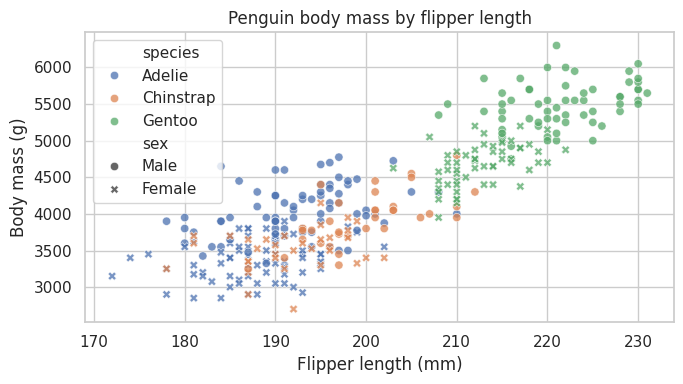

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=penguins_with_sex,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    style="sex",
    alpha=0.75,
    ax=ax,
)
ax.set(
    title="Penguin body mass by flipper length",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
)
fig.tight_layout()
plt.show()

BONUS 2: Create a second version without `style="sex"` and decide which is easier to read.

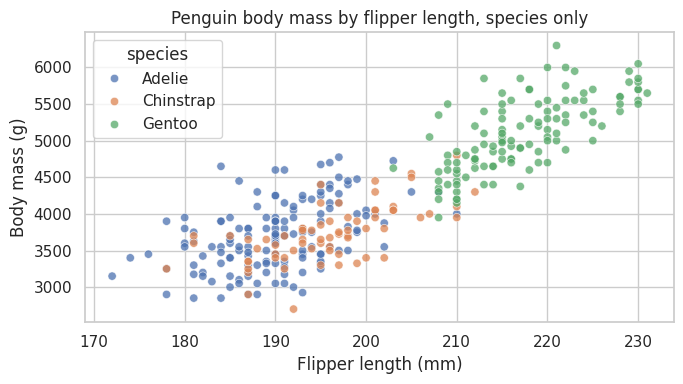

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=penguins_with_sex,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    alpha=0.75,
    ax=ax,
)
ax.set(
    title="Penguin body mass by flipper length, species only",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
)
fig.tight_layout()
plt.show()

## Exercise 2: Polish with matplotlib

1. Create `fig, ax = plt.subplots(figsize=(7, 4))`.
2. Draw a seaborn scatter plot of `flipper_length_mm` vs. `body_mass_g`, with
   `hue="species"`, on that `ax`.
3. Add a dashed vertical reference line at the median of `flipper_length_mm`.
4. Annotate the median line with the median value rounded to one decimal place.
5. Add the title `Body mass by flipper length` and clear axis labels.
6. Remove the top and right spines and call `fig.tight_layout()`.
7. BONUS: Add a light grid with `alpha=0.3`.
8. BONUS: Save the figure as `penguin_flipper_body_mass.png` with `dpi=300`
   and `bbox_inches="tight"`.

1-6. Create matplotlib figure, scatter plot with hue, reference line at median, annotation, title and labels.

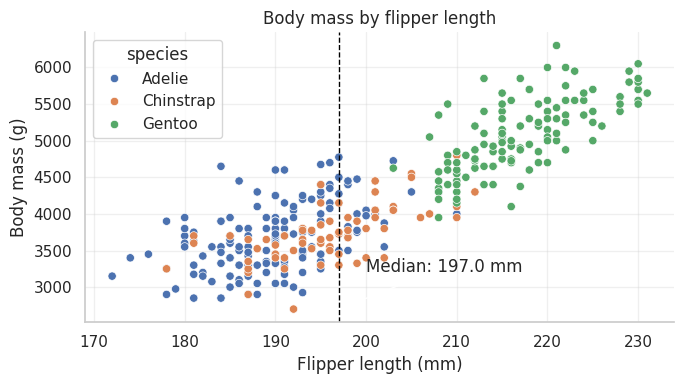

In [9]:
median_flipper = penguins["flipper_length_mm"].median()
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    ax=ax,
)
ax.axvline(median_flipper, color="black", linestyle="--", linewidth=1)
ax.annotate(
    f"Median: {median_flipper:.1f} mm",
    xy=(median_flipper, penguins["body_mass_g"].min()),
    xytext=(median_flipper + 3, penguins["body_mass_g"].min() + 500),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    title="Body mass by flipper length",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("penguin_flipper_body_mass.png", dpi=300, bbox_inches="tight")
plt.show()

## Exercise 3: Trends and grouped means

1. From `flights`, create a line plot of `passengers` over `period`.
2. Add the title `Monthly airline passengers` and label the axes `Year` and
   `Passengers`.
3. Filter `flights` to March and September, remove unused month categories,
   and plot both trends with `hue="month"` and `marker="o"`.
4. Title the filtered plot `March and September passenger trends`.
5. From `penguins`, drop rows with missing `sex` or `body_mass_g`.
6. Create a bar plot of mean `body_mass_g` by `species`, split by `sex`, using
   `errorbar=("ci", 95)`.
7. Add the title `Mean body mass by species and sex` and clear axis labels.
8. BONUS: Move the bar-plot legend to the upper left and give it the title
   `Sex`.
9. BONUS: Remove the top and right spines from the bar plot.

1-2. Create line plot of passengers over period with title and labels.

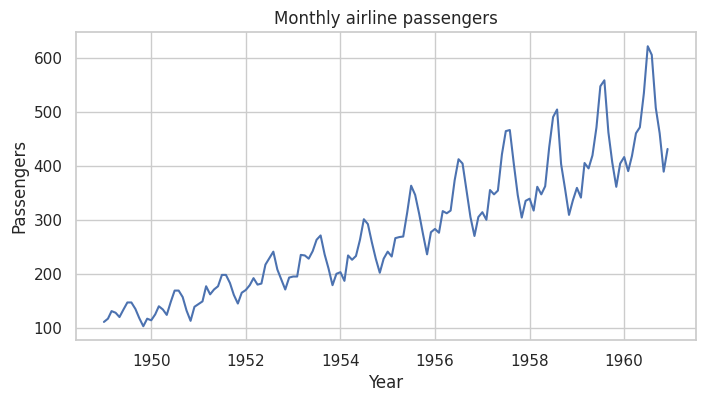

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=flights, x="period", y="passengers", ax=ax)
ax.set(title="Monthly airline passengers", xlabel="Year", ylabel="Passengers")
plt.show()

3-4. Filter flights to March and September, remove unused categories, plot with hue and markers.

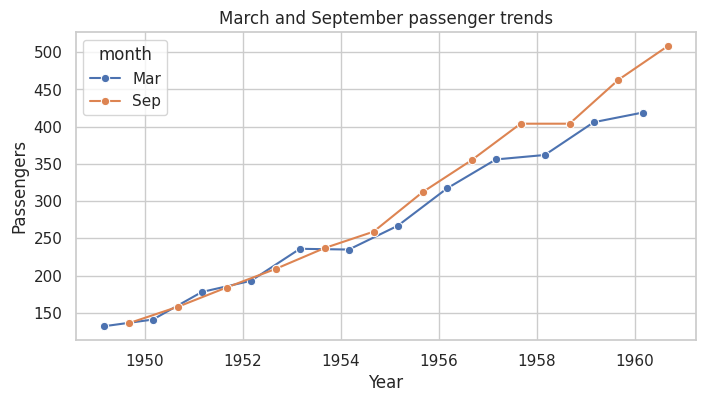

In [11]:
selected = flights[flights["month"].isin(["Mar", "Sep"])].copy()
selected["month"] = selected["month"].cat.remove_unused_categories()
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=selected, x="period", y="passengers", hue="month", marker="o", ax=ax)
ax.set(title="March and September passenger trends", xlabel="Year", ylabel="Passengers")
plt.show()

5-7. Drop missing rows, create bar plot of mean body mass by species and sex with error bars.

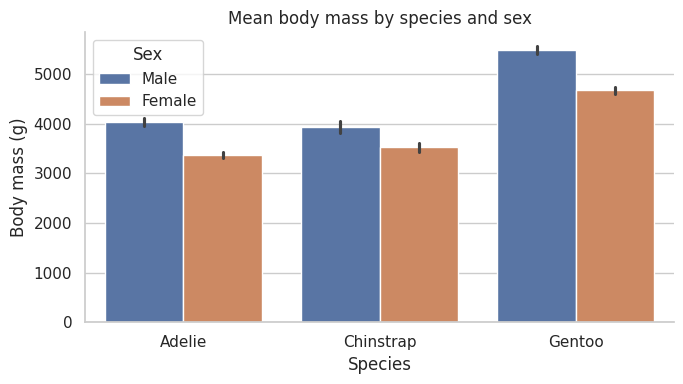

In [12]:
penguin_mass = penguins.dropna(subset=["species", "sex", "body_mass_g"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=penguin_mass,
    x="species",
    y="body_mass_g",
    hue="sex",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set(
    title="Mean body mass by species and sex", xlabel="Species", ylabel="Body mass (g)"
)
sns.move_legend(ax, "upper left", title="Sex", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Exercise 4: Distributions and categories

1. Create a combined histogram and density plot comparing `body_mass_g`
   distributions by `species`.
2. Use `bins=20`, `stat="density"`, `common_norm=False`, `element="step"`,
   and `kde=True`.
3. Add the title `Penguin body mass distributions by species` and label the
   axes `Body mass (g)` and `Density`.
4. Drop rows with missing `sex` or `body_mass_g`, then create box plots of
   `body_mass_g` by `species` and `sex`.
5. Add the title `Body mass spread by species and sex` and clear axis labels.
6. Create violin plots for the same species-and-sex comparison.
7. Add the title `Body mass distribution shape by species and sex` and compare
   the violin plot with the box plot.
8. BONUS: Use the same `species_order` for both the box plot and violin plot.
9. BONUS: State which plot better shows distribution shape and which plot is
   clearer for medians and outliers.

1-3. Create histogram with density and KDE showing body_mass_g by species with title and labels.

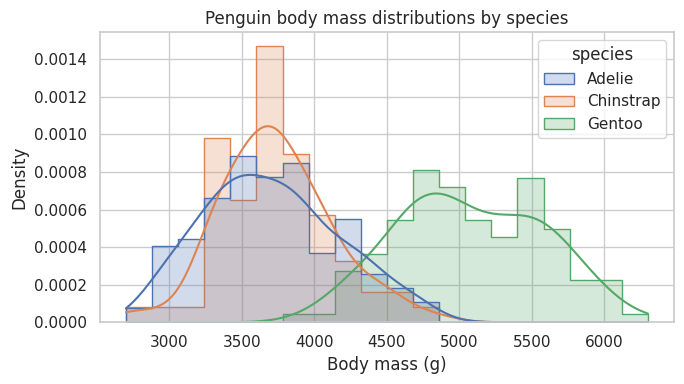

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=penguins,
    x="body_mass_g",
    hue="species",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False,
    element="step",
    ax=ax,
)
ax.set(
    title="Penguin body mass distributions by species",
    xlabel="Body mass (g)",
    ylabel="Density",
)
fig.tight_layout()
plt.show()

4-5. Drop missing rows, create box plots of body_mass_g by species and sex with title and labels.

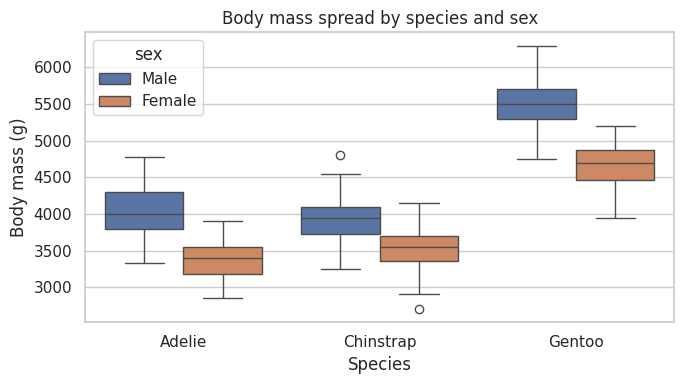

In [14]:
penguins_with_sex = penguins.dropna(subset=["species", "sex", "body_mass_g"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=penguins_with_sex,
    x="species",
    y="body_mass_g",
    hue="sex",
    order=species_order,
    ax=ax,
)
ax.set(
    title="Body mass spread by species and sex",
    xlabel="Species",
    ylabel="Body mass (g)",
)
fig.tight_layout()
plt.show()

6-7. Create violin plots for species and sex comparison with title and labels.

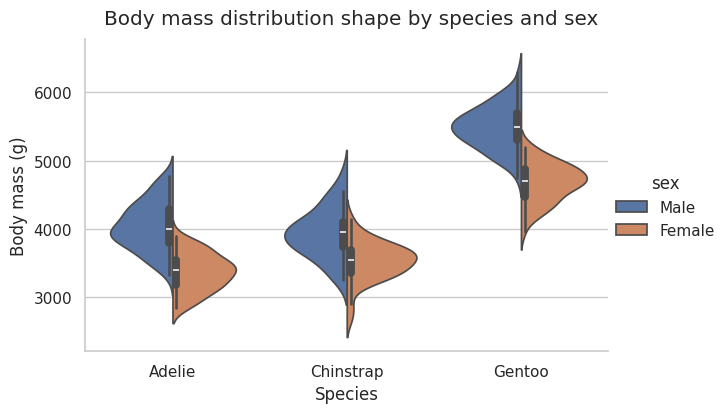

In [15]:
g = sns.catplot(
    data=penguins_with_sex,
    kind="violin",
    x="species",
    y="body_mass_g",
    hue="sex",
    order=species_order,
    split=True,
    height=4,
    aspect=1.6,
)
g.set_axis_labels("Species", "Body mass (g)")
g.fig.suptitle("Body mass distribution shape by species and sex", y=1.03)
plt.show()

Violin plots show distribution shape most directly; box plots are clearer for
medians, interquartile ranges, and potential outliers.

## Exercise 5: Relationship summaries

Use `penguins`.

1. Select `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and
   `body_mass_g`; exclude `year`.
2. Compute the correlation matrix and draw an annotated heatmap centered on
   zero.
3. Add the title `Penguins measurement correlations`.
9. BONUS: Use a diverging colormap and square cells in the heatmap.

1-3. Select measurement columns, compute correlation matrix, draw annotated heatmap with title.

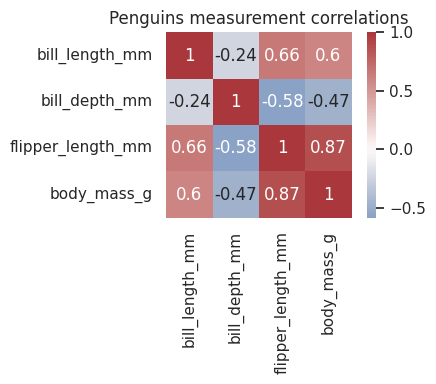

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    penguins[measurement_cols].corr(),
    annot=True,
    center=0,
    cmap="vlag",
    square=True,
    ax=ax,
)
ax.set(title="Penguins measurement correlations")
fig.tight_layout()
plt.show()

## Exercise 6: FacetGrid for small multiples

Use `penguins`. Build a faceted figure comparing body-size measurements across
species and sex using `FacetGrid`.

1. Drop rows with missing `species`, `sex`, `flipper_length_mm`, or `body_mass_g`.
2. Create a `FacetGrid` with `col="species"`, `row="sex"`, `margin_titles=True`, and `height=4`.
3. Use `g.map_dataframe(sns.scatterplot, ...)` to plot `x="flipper_length_mm"` and `y="body_mass_g"`.
4. Add `hue="species"` to the scatterplot to encode species with color.
5. Use `g.set_axis_labels("Flipper length (mm)", "Body mass (g)")`.
6. Set figure-level titles using `g.set_titles(col_template="{col_name}", row_template="{row_name}")`.
7. Call `plt.tight_layout()` before displaying.
8. BONUS: Add `alpha=0.6` to the scatterplot to handle overplotting.
9. BONUS: Create a second version using `kind="violin"` instead of scatterplot and compare the clarity of each approach.
10. BONUS: Explore `g.set(ylim=(min_val, max_val))` to set consistent y-axis limits across all panels.

1. Drop rows with missing `species`, `sex`, `flipper_length_mm`, or `body_mass_g`.

In [17]:
penguins_grid = penguins.dropna(subset=["species", "sex", "flipper_length_mm", "body_mass_g"])

2-7. Create `FacetGrid` with row and column faceting, map scatterplot with hue encoding, set labels and titles.

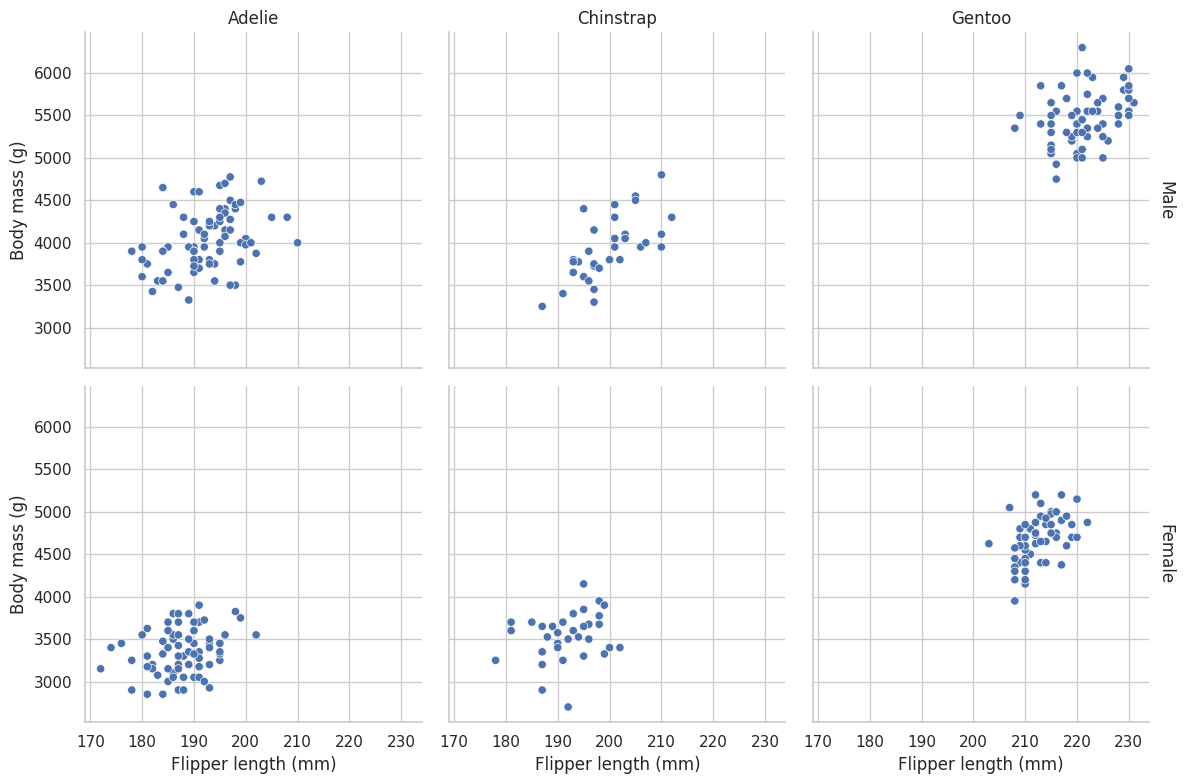

In [18]:
g = sns.FacetGrid(
    penguins_grid,
    col="species",
    row="sex",
    margin_titles=True,
    height=4,
)
g.map_dataframe(
    sns.scatterplot,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
)
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

BONUS 1: Add `alpha=0.6` to handle overplotting.

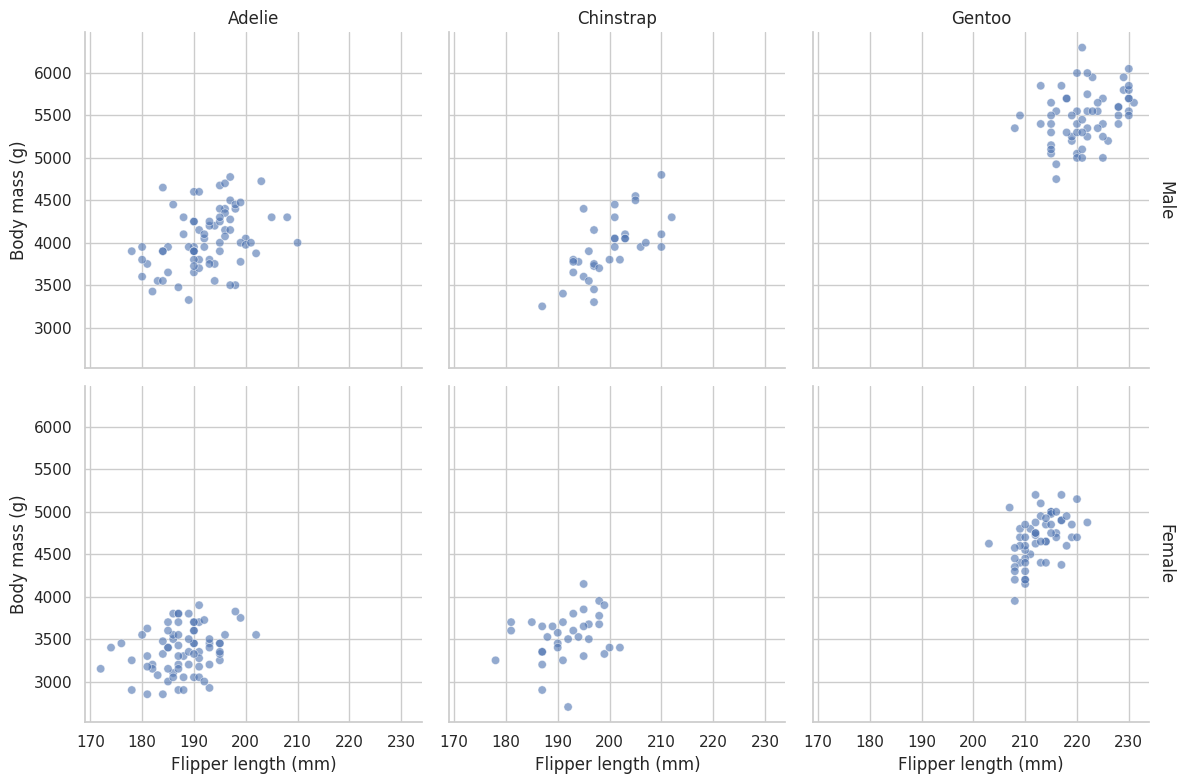

In [19]:
g = sns.FacetGrid(
    penguins_grid,
    col="species",
    row="sex",
    margin_titles=True,
    height=4,
)
g.map_dataframe(
    sns.scatterplot,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    alpha=0.6,
)
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

BONUS 2: Compare with violin plots instead of scatterplot.

/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/tobias/data_prep_workshop/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


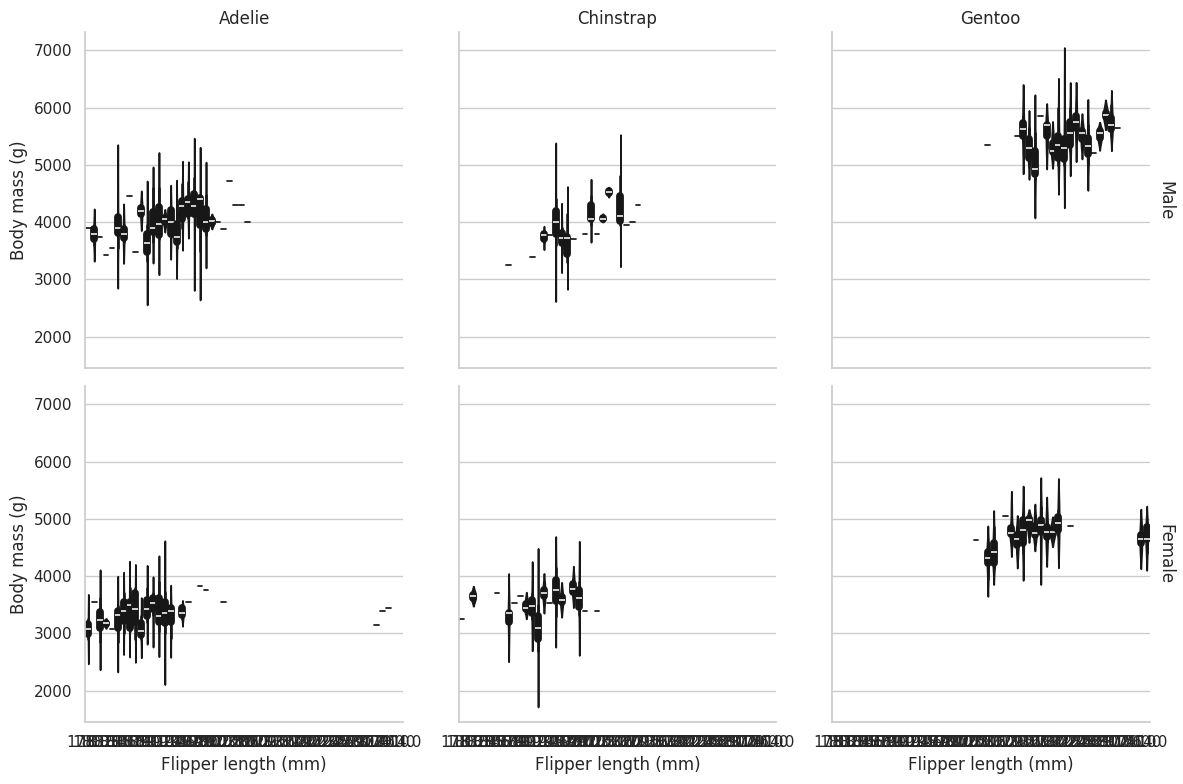

In [20]:
g = sns.FacetGrid(
    penguins_grid,
    col="species",
    row="sex",
    margin_titles=True,
    height=4,
)
g.map_dataframe(
    sns.violinplot,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
)
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

BONUS 3: Set consistent y-axis limits across all panels.

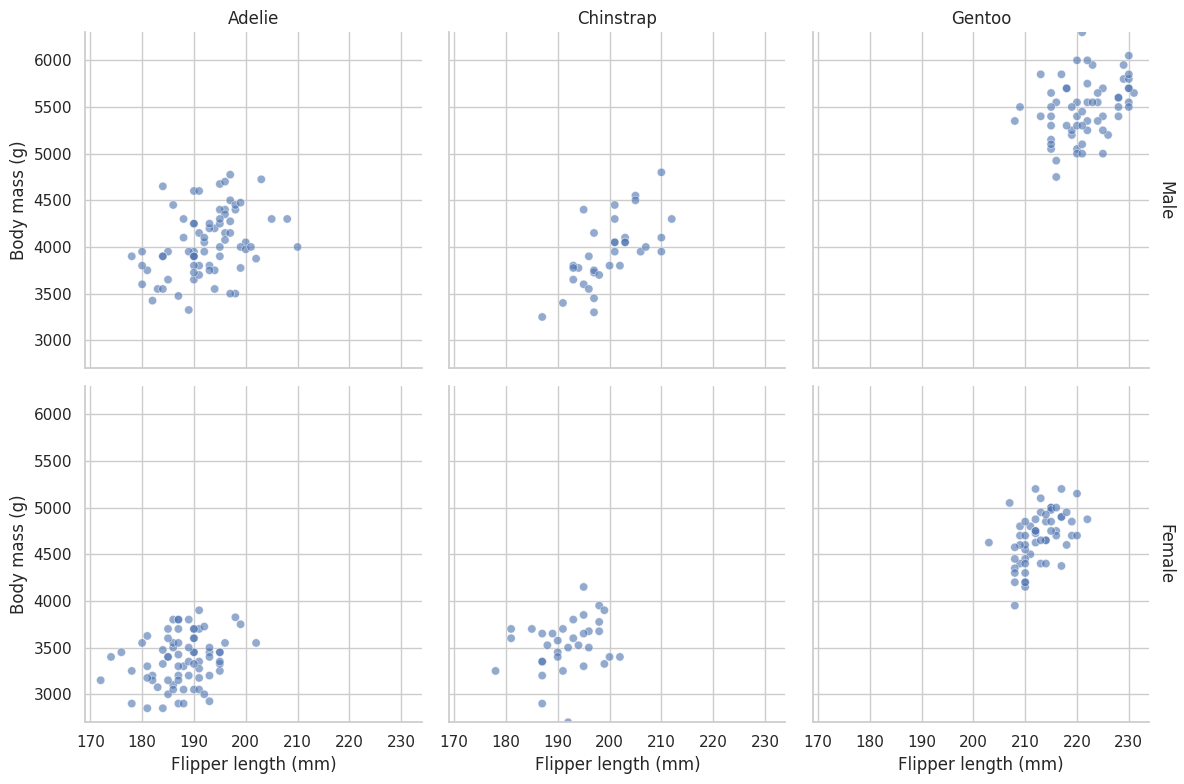

In [21]:
min_mass = penguins_grid["body_mass_g"].min()
max_mass = penguins_grid["body_mass_g"].max()

g = sns.FacetGrid(
    penguins_grid,
    col="species",
    row="sex",
    margin_titles=True,
    height=4,
)
g.map_dataframe(
    sns.scatterplot,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    alpha=0.6,
)
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set(ylim=(min_mass, max_mass))
plt.tight_layout()
plt.show()